<a href="https://colab.research.google.com/github/lolndo/Basic_Networks3/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%D0%94%D0%97_Lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Задание

Создайте нейронную сеть, распознающую рукописные цифры. Используя подготовленную базу и шаблон ноутбука, нормируйте данные, создайте и обучите сверточную сеть.

**Параметры модели:** сеть должна содержать минимум 2 сверточных слоя; полносвязные слои; слои подвыборки, нормализации, регуляризации по 1 шт.

**Гиперпараметры обучения:** функция ошибки - категориальная кроссэнтропия, оптимизатор - Adam с шагом обучения одна тысячная, размер батча - 128, количество эпох 15, детали обучения - отображать.

**В конце** выведите график обучения: доли верных ответов на обучающей и проверочной выборках.


In [1]:
# загрузка датасета MNIST

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Подключение утилит для to_categorical
from tensorflow.keras import utils

# Подключение библиотеки для работы с массивами
import numpy as np

# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt

# Подключение библиотеки для генерации случайных чисел
import random

# Подключение класса для работы с изображением
from PIL import Image

# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

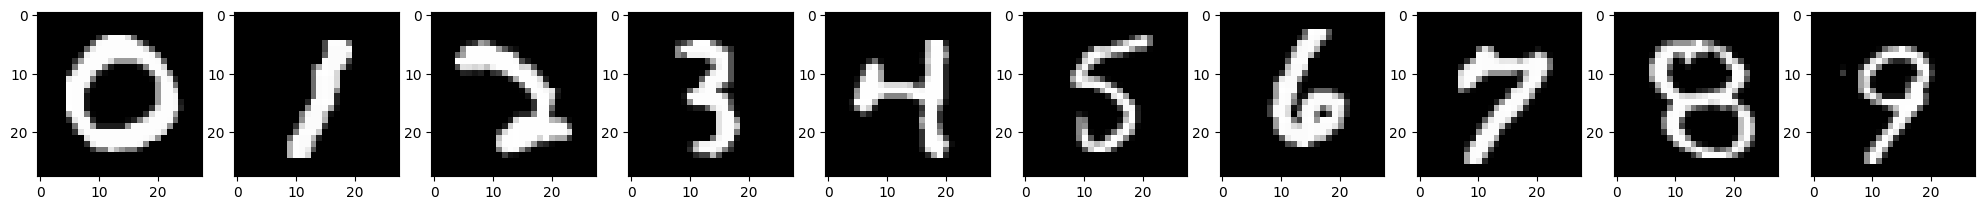

In [3]:
# вывод изображений каждого класса для ознакомления с датасетом

fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
  label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
  index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
  img = x_train[index] # выбираем из x_train нужное положение
  axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

In [4]:
# добавляем размерность массиву mnist, чтобы сеть поняла что это чб
x_train = x_train.reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2], 1)
x_test = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)

# преобразуем выборки с ответами в OHE
y_train = utils.to_categorical(y_train, 10)
y_test = utils.to_categorical(y_test, 10)

# посмотрим форматы выборок перед обучением
print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print()
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)

y_train: (60000, 10)
y_test: (10000, 10)


In [ ]:
# Ваше решение

In [6]:
#Нормализация данных
x_train = x_train / 255.0
x_test = x_test / 255.0

#Импорт необходимых слоёв и оптимизатора
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


In [7]:
#Создание модели
model = Sequential([
    # Первый свёрточный слой
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),          # Слой нормализации
    MaxPooling2D((2, 2)),          # Слой подвыборки
    # Второй свёрточный слой
    Conv2D(64, (3, 3), activation='relu'),
    # Полносвязные слои
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),                  # Слой регуляризации
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Компиляция модели
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Обучение модели
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 63s 160ms/step - accuracy: 0.9078 - loss: 0.3019 - val_accuracy: 0.9808 - val_loss: 0.3601
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 61s 162ms/step - accuracy: 0.9680 - loss: 0.1076 - val_accuracy: 0.9857 - val_loss: 0.0492
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 157ms/step - accuracy: 0.9767 - loss: 0.0788 - val_accuracy: 0.9890 - val_loss: 0.0415
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - accuracy: 0.9808 - loss: 0.0632 - val_accuracy: 0.9902 - val_loss: 0.0417
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 161ms/step - accuracy: 0.9844 - loss: 0.0518 - val_accuracy: 0.9889 - val_loss: 0.0403
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 162ms/step - accuracy: 0.9863 - loss: 0.0448 - val_accuracy: 0.9897 - val_loss: 0.0393
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.9877 - loss: 0.0385 - val_accuracy: 0.9905 - val_loss: 0.0390
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.9889 - loss: 0

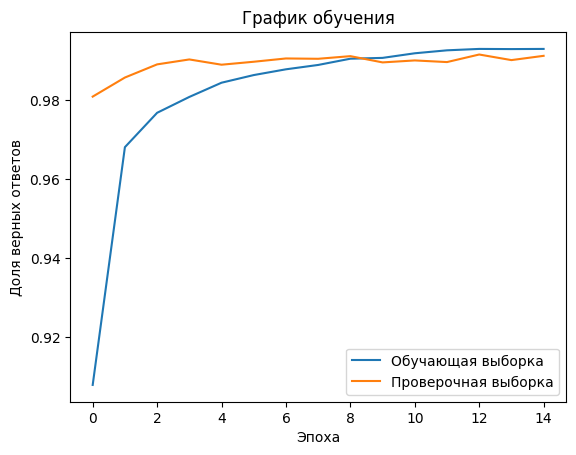

In [9]:
# График доли верных ответов на обучении и проверке
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Обучающая выборка')
plt.plot(history.history['val_accuracy'], label='Проверочная выборка')
plt.xlabel('Эпоха')
plt.ylabel('Доля верных ответов')
plt.title('График обучения')
plt.legend()
plt.show()